<a href="https://colab.research.google.com/github/pratikmojumder/Diagrams_Creation/blob/main/Bar_Diagram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

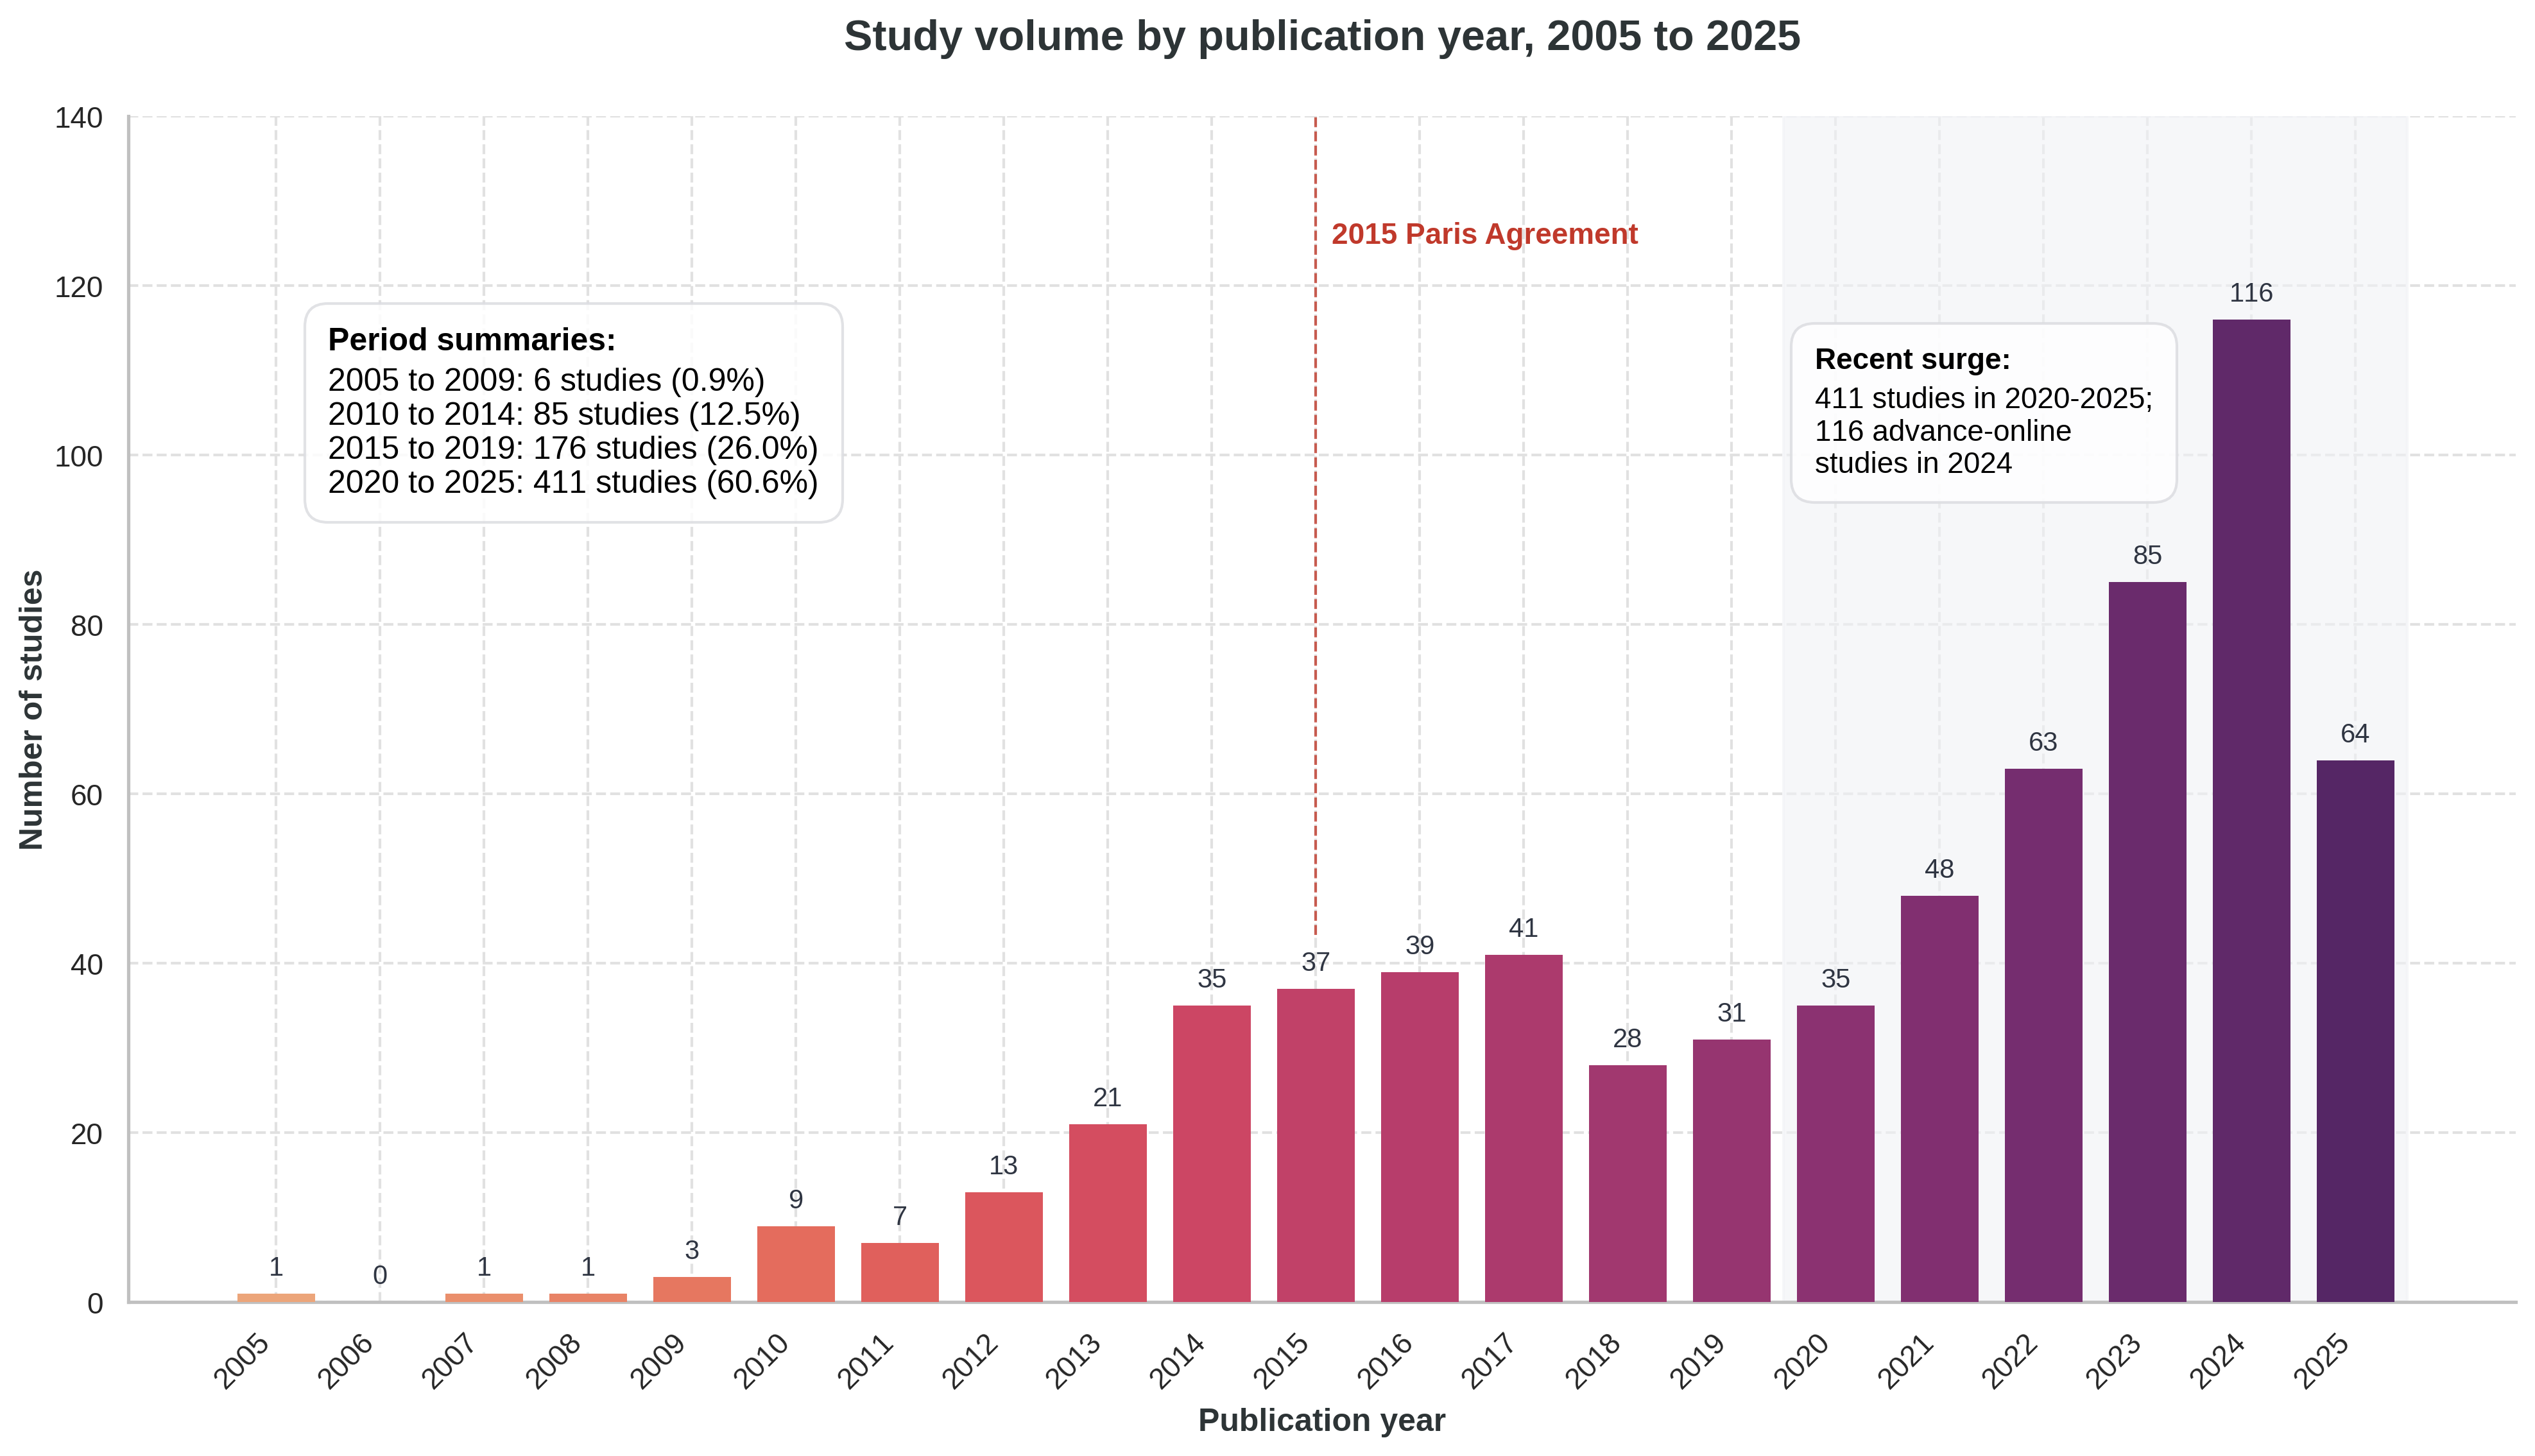

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.offsetbox import AnnotationBbox, TextArea, VPacker
# 1. Data Definitions
years = [
    '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014',
    '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025'
]

studies = [
    1, 0, 1, 1, 3, 9, 7, 13, 21, 35,
    37, 39, 41, 28, 31, 35, 48, 63, 85, 116, 64
]

# 2. Styling and Configuration
sns.set_theme(style="whitegrid", rc={"grid.color": "#e1e1e1", "grid.linestyle": "--"})
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Liberation Sans', 'Arial', 'Helvetica', 'DejaVu Sans']
})

fig, ax = plt.subplots(figsize=(16, 8), dpi=300)
colors = sns.color_palette("flare", n_colors=len(years))

# 3. Plotting
bars = ax.bar(years, studies, color=colors, edgecolor='none', width=0.75, zorder=3)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2., height + 1.5,
        f'{int(height)}',
        ha='center', va='bottom', fontsize=10, color='#2f3542', fontweight='500'
    )

# 4. Annotations and Highlights
idx_2015 = years.index('2015')
ax.axvline(x=idx_2015, ymin=0.31, color='#c0392b', linestyle='--', linewidth=1, alpha=0.8, zorder=2)
ax.text(idx_2015 + 0.15, 125, '2015 Paris Agreement', color='#c0392b', fontsize=11, fontweight='bold')

idx_2020 = years.index('2020')
idx_2025 = years.index('2025')
ax.axvspan(idx_2020 - 0.5, idx_2025 + 0.5, color='#f1f2f6', alpha=0.6, zorder=1)

# 5. Shared Annotation Styles
bbox_style = dict(facecolor='white', edgecolor='#dcdde1', boxstyle='round,pad=0.8', alpha=0.85)

# 6. Surge Information Box (Using VPacker for mixed text formatting)
surge_total = sum(studies[idx_2020 : idx_2025 + 1])
studies_2024 = studies[years.index('2024')]

# Create the bold header
surge_header = TextArea(
    "Recent surge:",
    textprops=dict(fontsize=11, color="black", fontweight="bold"),
)

# Create the regular weight body text
surge_body_text = (
    f"{surge_total} studies in 2020-2025;\n"
    f"{studies_2024} advance-online\n"
    f"studies in 2024"
)
surge_body = TextArea(surge_body_text, textprops=dict(fontsize=11, color="black"))

# Pack them vertically
surge_packer = VPacker(children=[surge_header, surge_body], align="left", pad=0, sep=4)

# Render the packed box at the same coordinates
surge_annotation = AnnotationBbox(
    surge_packer,
    xy=(14.8, 105),
    xycoords="data",
    box_alignment=(0, 0.5), # Matches ha='left', va='center'
    bboxprops=bbox_style,
    frameon=True,
)
ax.add_artist(surge_annotation)

# 7. Period Summaries Box (Using VPacker for mixed text formatting)
total_studies = sum(studies)
p1 = sum(studies[years.index("2005") : years.index("2009") + 1])
p2 = sum(studies[years.index("2010") : years.index("2014") + 1])
p3 = sum(studies[years.index("2015") : years.index("2019") + 1])
p4 = surge_total

# Create the bold header
header_box = TextArea(
    "Period summaries:",
    textprops=dict(fontsize=12, color="black", fontweight="bold"),
)

# Create the regular weight body text
body_text = (
    f"2005 to 2009: {p1} studies ({p1/total_studies:.1%})\n"
    f"2010 to 2014: {p2} studies ({p2/total_studies:.1%})\n"
    f"2015 to 2019: {p3} studies ({p3/total_studies:.1%})\n"
    f"2020 to 2025: {p4} studies ({p4/total_studies:.1%})"
)
body_box = TextArea(body_text, textprops=dict(fontsize=12, color="black"))

# Pack them vertically with a small separation (sep=4)
summary_packer = VPacker(children=[header_box, body_box], align="left", pad=0, sep=4)

# Render the packed box at the same coordinates
# box_alignment=(0, 0.5) matches ha='left', va='center'
summary_annotation = AnnotationBbox(
    summary_packer,
    xy=(0.5, 105),
    xycoords="data",
    box_alignment=(0, 0.5),
    bboxprops=dict(
        facecolor="white", edgecolor="#dcdde1", boxstyle="round,pad=0.8", alpha=0.85
    ),
    frameon=True,
)
ax.add_artist(summary_annotation)

# 8. Axes Formatting
ax.set_title("Study volume by publication year, 2005 to 2025", fontsize=16, fontweight='bold', color='#2d3436', pad=25)
ax.set_ylabel("Number of studies", fontsize=12, color='#2d3436', fontweight='bold', labelpad=2)
ax.set_xlabel("Publication year", fontsize=12, color='#2d3436', fontweight='bold', labelpad=5)

ax.set_ylim(0, 140)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

sns.despine(ax=ax)
ax.spines['left'].set_color('#c0c0c0')
ax.spines['bottom'].set_color('#c0c0c0')

# 9. Save files
plt.savefig('Output_diagram.png', bbox_inches='tight', dpi=300)
plt.savefig('Output_diagram.pdf', bbox_inches='tight')
plt.show()